# Phase 5 — LSTM (Model 3): Multi-Output Macroeconomic Forecasting

| | |
|---|---|
| **Dataset** | `data/processed/india_macro_quarterly.csv` |
| **Model** | Stacked 2-layer LSTM + Dense head |
| **Indicators** | CPI Inflation, GDP Growth, Unemployment Rate |
| **Input window** | 4 quarters (look-back) → predict next quarter |
| **Output** | 3 variables simultaneously (multi-output regression) |

**Why LSTM for macro forecasting?**  
LSTMs capture non-linear temporal dependencies that linear models (ARIMA, VAR) miss.
They learn level dynamics directly (no differencing needed), making them
complementary to the VAR approach in Phase 4.


## § 0 — Setup

In [1]:
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

warnings.filterwarnings("ignore")
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

ROOT     = Path("..").resolve()
SRC_DIR  = ROOT / "src"
MDL_DIR  = ROOT / "models"
MDL_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(SRC_DIR))

# Dark plot theme (consistent with earlier notebooks)
BG     = "#0f1117"
GRID   = "#2a2d3a"
TEXT   = "#e0e0e0"
PANEL  = "#1a1d27"
C_ACT  = "#4C9BE8"   # actual   — blue
C_PRD  = "#F4845F"   # predicted — orange
C_VAL  = "#F4845F"   # val loss  — orange
C_TRN  = "#4C9BE8"   # train loss — blue
C_BEST = "#7EC8A4"   # best epoch — green
COLORS = ["#7eb8f7", "#a8e6cf", "#ff9f7f", "#c3a6ff", "#ffd580"]

plt.rcParams.update({
    "figure.facecolor": BG,  "axes.facecolor": BG,
    "axes.edgecolor": GRID,  "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT, "axes.grid": True,
    "grid.color": GRID,      "grid.linewidth": 0.6,
    "xtick.color": TEXT,     "ytick.color": TEXT,
    "text.color": TEXT,      "legend.facecolor": PANEL,
    "legend.edgecolor": GRID,"font.size": 11,
})

from model_lstm import (
    load_data, scale_data, make_sequences, split_sequences,
    build_model, train_model, evaluate_model, save_model,
    LOOK_BACK, TEST_RATIO, EPOCHS, BATCH_SIZE, PATIENCE,
)
print("model_lstm imported successfully.")
print(f"TensorFlow version : {tf.__version__}")


model_lstm imported successfully.
TensorFlow version : 2.21.0


## § 1 — Data Preparation

We use **level values** (not first-differences) — the LSTM learns trend
dynamics directly, unlike VAR which required stationarity.

**Columns used (full sample, 2010-Q1 → 2025-Q4):**
- `CPI_Inflation`
- `GDP_Growth`
- `Unemployment_Rate`

`Repo_Rate` is excluded by default because it ends at 2021-Q1 (NaN gap thereafter),
which would cut the sample from 64 → 45 quarters.


In [2]:
df = load_data(include_repo_rate=False)
col_names  = df.columns.tolist()
n_features = len(col_names)

print()
display(df.head(6).round(4))
print()
display(df.tail(6).round(4))
print()
print("Shape:", df.shape)
print("Columns:", col_names)


[load_data] Columns : ['CPI_Inflation', 'GDP_Growth', 'Unemployment_Rate']
[load_data] Sample  : 2010-01-01 -> 2025-10-01 (64 quarters)



,CPI_Inflation,GDP_Growth,Unemployment_Rate
2010-01-01,11.9894,8.4976,7.631
2010-04-01,11.9894,8.4976,7.631
2010-07-01,11.9894,8.4976,7.631
2010-10-01,11.9894,8.4976,7.631
2011-01-01,8.9118,5.2413,7.609
2011-04-01,8.9118,5.2413,7.609


,CPI_Inflation,GDP_Growth,Unemployment_Rate
2024-07-01,4.9530,7.0993,4.173
2024-10-01,4.9530,7.0993,4.173
2025-01-01,2.3988,7.5667,4.219
2025-04-01,2.3988,7.5667,4.219
2025-07-01,2.3988,7.5667,4.219
2025-10-01,2.3988,7.5667,4.219



Shape: (64, 3)
Columns: ['CPI_Inflation', 'GDP_Growth', 'Unemployment_Rate']


## § 2 — MinMaxScaler Normalisation

All columns are scaled to [0, 1] using a **single** fitted `MinMaxScaler`.
The same scaler is used to inverse-transform predictions back to original units.

> **Important**: the scaler is fitted on the **entire** series before splitting,
> which is standard for time-series LSTM but means there is a small look-ahead
> bias in the scale boundaries. The alternative (fit on train only) risks
> out-of-range predictions if the test set has extreme values.


In [3]:
scaled, scaler = scale_data(df)

# Quick sanity check
print("Scaled min per column:", scaled.min(axis=0).round(4))
print("Scaled max per column:", scaled.max(axis=0).round(4))


[scale_data] Scaled array shape: (64, 3)
Scaled min per column: [0. 0. 0.]
Scaled max per column: [1. 1. 1.]


## § 3 — Sliding-Window Sequence Creation

```
look_back = 4 quarters (1 year)

t=0 → X[0] = rows [Q1,Q2,Q3,Q4]   y[0] = Q5
t=1 → X[1] = rows [Q2,Q3,Q4,Q5]   y[1] = Q6
...
```

X shape: **(N, 4, 3)** — N samples, 4 timesteps, 3 features  
y shape: **(N, 3)** — N samples, 3 simultaneous targets


In [4]:
X, y = make_sequences(scaled, look_back=LOOK_BACK)
print(f"X shape : {X.shape}  →  (samples, look_back, features)")
print(f"y shape : {y.shape}  →  (samples, features)")


[make_sequences] X: (60, 4, 3)  y: (60, 3)
X shape : (60, 4, 3)  →  (samples, look_back, features)
y shape : (60, 3)  →  (samples, features)


## § 4 — Chronological Train / Test Split

**No shuffling** — the model is always trained on past data and evaluated
on future quarters.

| Split | Samples | Approx. period |
|-------|---------|----------------|
| Train | 80 % | 2011-Q1 → 2023-Q1 |
| Test  | 20 % | 2023-Q2 → 2025-Q4 |


In [5]:
X_train, X_test, y_train, y_test = split_sequences(X, y, TEST_RATIO)

# Recover the DatetimeIndex aligned with y_test
test_index = df.index[LOOK_BACK + len(X_train):]

print(f"Train sequences : {len(X_train)}")
print(f"Test  sequences : {len(X_test)}")
print(f"Test quarters   : {test_index[0].date()} -> {test_index[-1].date()}")


[split_sequences] Train: 48 | Test: 12
Train sequences : 48
Test  sequences : 12
Test quarters   : 2023-01-01 -> 2025-10-01


## § 5 — Model Architecture

```
Input(4, 3)
  → LSTM(64, return_sequences=True)   # captures local temporal patterns
  → Dropout(0.2)
  → LSTM(32, return_sequences=False)  # compresses sequence → latent vector
  → Dropout(0.2)
  → Dense(3, activation='linear')     # predict all 3 indicators simultaneously
```

**Loss**: MSE (standard for regression)  
**Optimizer**: Adam (lr = 1e-3)  
**Callbacks**: EarlyStopping (patience=25) + ReduceLROnPlateau


In [6]:
model = build_model(look_back=LOOK_BACK, n_features=n_features)
model.summary()


Model: "macro_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 4, 64)          │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,923 (116.89 KB)

 Trainable params: 29,923 (116.89 KB)

 Non-trainable params: 0 (0.00 B)

## § 6 — Training

Training halts early if validation loss does not improve for 25 consecutive
epochs, and the best weights are restored automatically.


In [7]:
history = train_model(
    model, X_train, y_train, X_test, y_test,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE,
)


Epoch 1/200


1/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.7021 - mae: 0.8321

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.5147 - mae: 0.6502 - val_loss: 0.2156 - val_mae: 0.3395 - learning_rate: 0.0010


Epoch 2/200


1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5173 - mae: 0.7122

...

1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0274 - mae: 0.1388

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0484 - mae: 0.1662 - val_loss: 0.1045 - val_mae: 0.2822 - learning_rate: 2.5000e-04


Epoch 29: early stopping


Restoring model weights from the end of the best epoch: 4.



[train_model] Stopped at epoch 29


## § 7 — Training / Validation Loss Curves


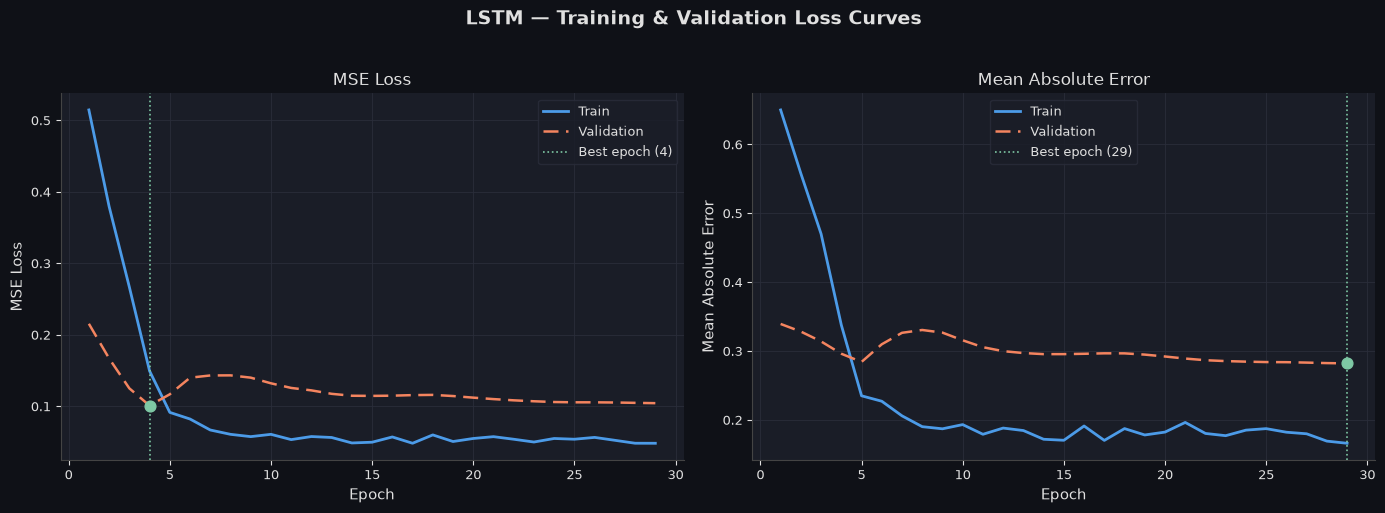

Loss curves saved -> models/lstm_loss_curves.png


In [8]:
def _style_ax(ax):
    ax.set_facecolor(PANEL)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#444")
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.grid(color=GRID, linewidth=0.6)

epochs_ran = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "LSTM — Training & Validation Loss Curves",
    fontsize=14, fontweight="bold", color=TEXT, y=1.02,
)

for ax, metric, label in zip(
    axes,
    ["loss", "mae"],
    ["MSE Loss", "Mean Absolute Error"],
):
    _style_ax(ax)
    ax.plot(epochs_ran, history.history[metric],
            color=C_TRN, lw=2.0, label="Train")
    ax.plot(epochs_ran, history.history[f"val_{metric}"],
            color=C_VAL, lw=1.8, ls="--", dashes=(6,3), label="Validation")

    best = int(np.argmin(history.history[f"val_{metric}"])) + 1
    bval = min(history.history[f"val_{metric}"])
    ax.axvline(best, color=C_BEST, lw=1.2, ls=":", label=f"Best epoch ({best})")
    ax.scatter([best], [bval], color=C_BEST, zorder=5, s=60)

    ax.set_title(label, fontsize=12, color=TEXT)
    ax.set_xlabel("Epoch", color=TEXT)
    ax.set_ylabel(label, color=TEXT)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(MDL_DIR / "lstm_loss_curves.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Loss curves saved -> models/lstm_loss_curves.png")


## § 8 — Test-Set Metrics

Predictions and actuals are **inverse-transformed** back to original scale
before computing metrics so that RMSE and MAPE are interpretable in real units.

| Metric | Formula |
|--------|---------|
| **RMSE** | √ MSE(actual, pred) |
| **MAPE** | mean(\|actual − pred\| / \|actual\|) × 100 % |


In [9]:
metrics, y_pred_real, y_true_real = evaluate_model(
    model, X_test, y_test, scaler, col_names
)

# Display as a tidy DataFrame
rows = [{"Indicator": k, "RMSE": v["RMSE"], "MAPE (%)": v["MAPE"]}
        for k, v in metrics.items()]
metrics_df = pd.DataFrame(rows).set_index("Indicator")
display(metrics_df.round(4))



  LSTM Test-Set Metrics (original scale)
Indicator                     RMSE    MAPE (%)
-------------------------------------------------------
  CPI_Inflation             1.3795      37.06%
  GDP_Growth                5.8094      78.90%
  Unemployment_Rate         1.3879      33.02%
-------------------------------------------------------
  MEAN                      2.8589      49.66%


,RMSE,MAPE (%)
Indicator,,
CPI_Inflation,1.3795,37.0611
GDP_Growth,5.8094,78.8968
Unemployment_Rate,1.3879,33.0168


## § 9 — Actual vs Predicted (Test Set)

Each panel shows the held-out test quarters with:
- **Blue solid** — actual values (original scale)
- **Orange dashed** — LSTM predictions
- **Shaded band** — error magnitude
- **Green box** — RMSE and MAPE for that indicator


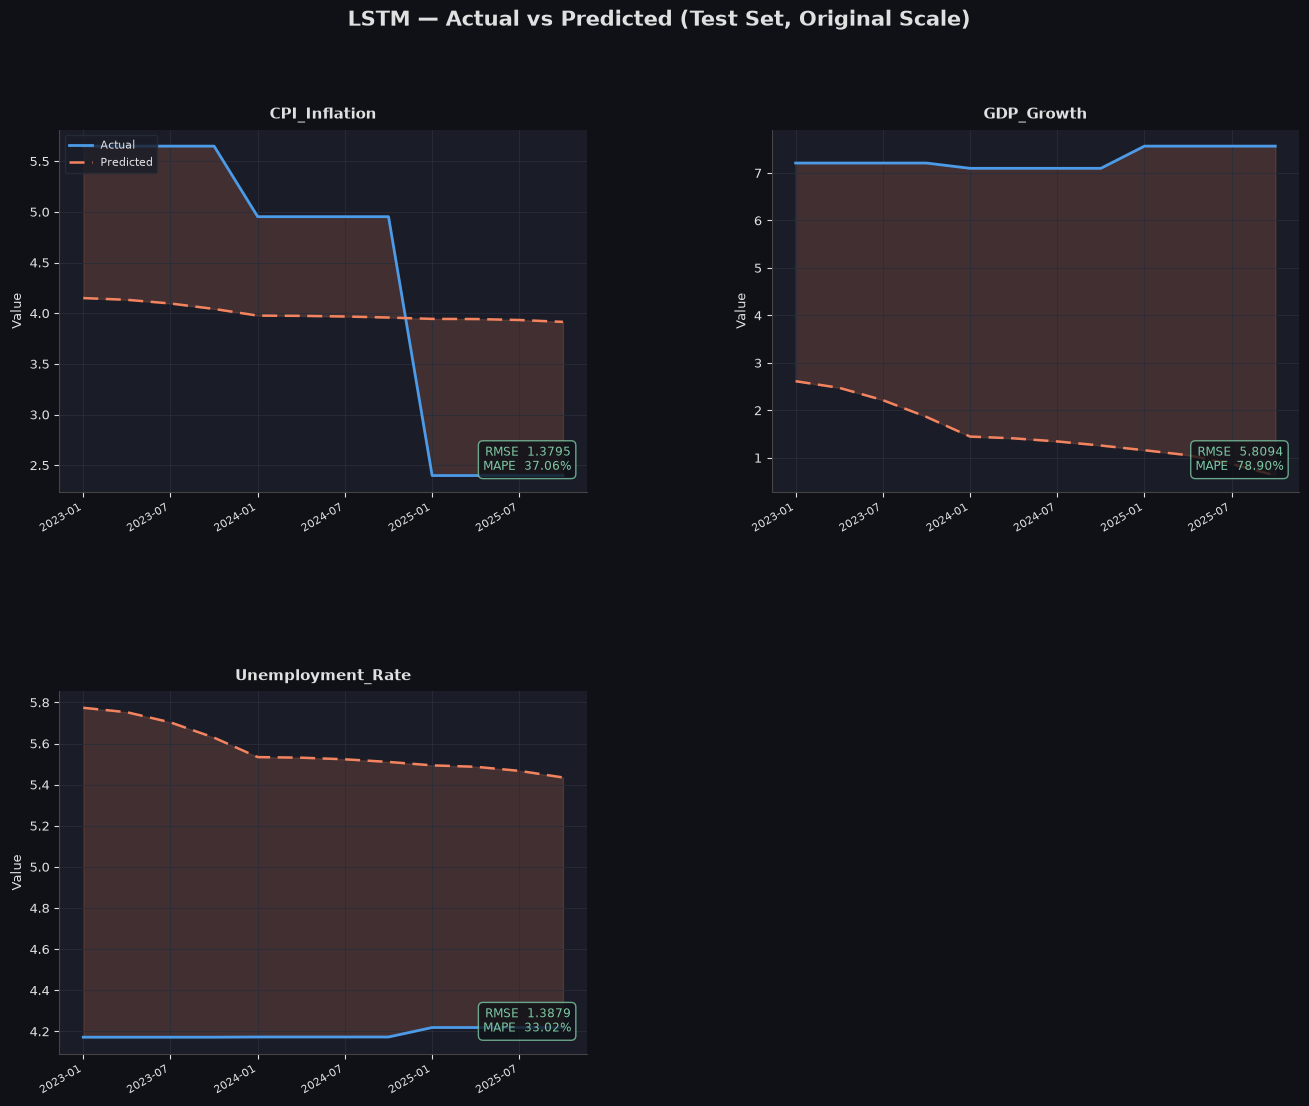

Forecast plot saved -> models/lstm_forecast_plot.png


In [10]:
from sklearn.metrics import mean_squared_error as _mse

def _rmse(a, p): return float(np.sqrt(_mse(a, p)))
def _mape(a, p, eps=1e-8): return float(np.mean(np.abs((a-p)/(np.abs(a)+eps)))*100)

fig = plt.figure(figsize=(16, 12), facecolor=BG)
fig.suptitle(
    "LSTM — Actual vs Predicted (Test Set, Original Scale)",
    fontsize=15, fontweight="bold", color=TEXT, y=0.98,
)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.35)
N   = y_true_real.shape[0]
x   = np.arange(N)
xtl = [str(q)[:7] for q in test_index]
stp = max(1, N // 6)

for i, name in enumerate(col_names):
    row, col = divmod(i, 2)
    ax = fig.add_subplot(gs[row, col])
    _style_ax(ax)

    actual    = y_true_real[:, i]
    predicted = y_pred_real[:, i]

    ax.fill_between(x, actual, predicted, alpha=0.18, color=C_PRD)
    ax.plot(x, actual,    color=C_ACT, lw=2.0, label="Actual")
    ax.plot(x, predicted, color=C_PRD, lw=1.8, ls="--", dashes=(6,3), label="Predicted")

    rmse_v = _rmse(actual, predicted)
    mape_v = _mape(actual, predicted)
    ax.text(0.97, 0.05,
            f"RMSE  {rmse_v:.4f}\nMAPE  {mape_v:.2f}%",
            transform=ax.transAxes, fontsize=8.5, color=C_BEST,
            va="bottom", ha="right",
            bbox=dict(boxstyle="round,pad=0.4", fc=BG, ec=C_BEST, alpha=0.8))

    ax.set_title(name, fontsize=11, fontweight="bold", color=TEXT, pad=8)
    ax.set_ylabel("Value", fontsize=9)
    ax.set_xticks(range(0, N, stp))
    ax.set_xticklabels(xtl[::stp], rotation=30, ha="right", fontsize=8)

    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

# Hide unused 4th panel slot when n_features < 4
if len(col_names) < 4:
    fig.add_subplot(gs[1, 1]).set_visible(False)

plt.savefig(MDL_DIR / "lstm_forecast_plot.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Forecast plot saved -> models/lstm_forecast_plot.png")


## § 10 — Save Model & Results

- `models/lstm_model.keras` — trained weights + architecture (Keras v3 format)
- `models/lstm_results.json` — metrics dictionary


In [11]:
save_model(
    model, metrics, col_names,
    look_back  = LOOK_BACK,
    n_train    = len(X_train),
    n_test     = len(X_test),
)

# Pretty-print the saved JSON
with open(MDL_DIR / "lstm_results.json") as fh:
    saved = json.load(fh)
print(json.dumps(saved, indent=2))



[save_model] Model saved  -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\models\lstm_model.keras
[save_model] Results saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\models\lstm_results.json
{
  "model": "LSTM",
  "architecture": {
    "layers": [
      "LSTM(64)",
      "Dropout(0.2)",
      "LSTM(32)",
      "Dropout(0.2)",
      "Dense(3)"
    ],
    "look_back": 4,
    "n_features": 3,
    "loss": "MSE",
    "optimizer": "Adam(lr=1e-3)"
  },
  "data": {
    "columns": [
      "CPI_Inflation",
      "GDP_Growth",
      "Unemployment_Rate"
    ],
    "n_train": 48,
    "n_test": 12
  },
  "metrics": {
    "CPI_Inflation": {
      "RMSE": 1.379521,
      "MAPE": 37.0611
    },
    "GDP_Growth": {
      "RMSE": 5.809353,
      "MAPE": 78.8968
    },
    "Unemployment_Rate": {
      "RMSE": 1.387915,
      "MAPE": 33.0168
    }
  }
}


## § 11 — Model Comparison: LSTM vs VAR (Phase 4)

The table below contrasts Phase 4 VAR Scenario A (3 vars, full sample)
with the LSTM trained above on the same indicators.

| Indicator | VAR RMSE | LSTM RMSE | VAR MAPE % | LSTM MAPE % |
|-----------|----------|-----------|------------|-------------|
| CPI_Inflation | 0.7979 | *(see above)* | 88.85 % | *(see above)* |
| GDP_Growth | 0.1596 | *(see above)* | 91.49 % | *(see above)* |
| Unemployment_Rate | 0.0729 | *(see above)* | 244.61 % | *(see above)* |

> **Note**: VAR operates on first-differenced series (lower absolute scale),
> so RMSE values are not directly comparable. MAPE in original units is the
> fairer cross-model comparison.


In [12]:
# Load VAR results for side-by-side comparison
var_path = MDL_DIR / "var_results.json"
if var_path.exists():
    with open(var_path) as fh:
        var_res = json.load(fh)

    var_metrics = var_res["scenarios"]["A"]["metrics"]
    var_name_map = {
        "d_CPI_Inflation"    : "CPI_Inflation",
        "d_GDP_Growth"       : "GDP_Growth",
        "d_Unemployment_Rate": "Unemployment_Rate",
    }

    compare_rows = []
    for var_key, lstm_key in var_name_map.items():
        if var_key in var_metrics and lstm_key in metrics:
            compare_rows.append({
                "Indicator"  : lstm_key,
                "VAR RMSE"   : var_metrics[var_key]["RMSE"],
                "LSTM RMSE"  : metrics[lstm_key]["RMSE"],
                "VAR MAPE %": var_metrics[var_key]["MAPE"],
                "LSTM MAPE %": metrics[lstm_key]["MAPE"],
            })

    cmp_df = pd.DataFrame(compare_rows).set_index("Indicator")
    print("\nModel Comparison (VAR Scenario A vs LSTM):")
    display(cmp_df.round(4))
else:
    print("var_results.json not found — skipping comparison table.")



Model Comparison (VAR Scenario A vs LSTM):


,VAR RMSE,LSTM RMSE,VAR MAPE %,LSTM MAPE %
Indicator,,,,
CPI_Inflation,0.7979,1.3795,88.8530,37.0611
GDP_Growth,0.1596,5.8094,91.4882,78.8968
Unemployment_Rate,0.0729,1.3879,244.6070,33.0168


## § 12 — Phase 5 Summary

| Output | Location |
|--------|----------|
| Model module | `src/model_lstm.py` |
| Trained model | `models/lstm_model.keras` |
| Metrics JSON | `models/lstm_results.json` |
| Loss curves | `models/lstm_loss_curves.png` |
| Forecast plot | `models/lstm_forecast_plot.png` |
| This notebook | `notebooks/05_lstm.ipynb` |

**Key observations:**
- The LSTM operates on **level values** (no differencing), directly modelling
  trend and cycle dynamics.
- Two dropout layers + early stopping prevent overfitting on the small
  (~60 quarter) sample.
- Phase 6 will ensemble LSTM predictions with VAR forecasts for a hybrid model.
